In [3]:
#STP1-Load and inspect data

import pandas as pd

In [4]:
aug=pd.read_csv('../data/raw/dublinbike-historical-data-2023-08.csv')
feb=pd.read_csv('../data/raw/dublinbike-historical-data-2023-02.csv')

print('August shape:', aug.shape)
print('Feb shape:', feb.shape)

aug.head()

August shape: (169404, 11)
Feb shape: (152903, 11)


,STATION ID,TIME,LAST UPDATED,NAME,BIKE_STANDS,AVAILABLE_BIKE_STANDS,AVAILABLE_BIKES,STATUS,ADDRESS,LATITUDE,LONGITUDE
0,1,2023-08-01 00:00:03,2023-07-31 23:57:52,CLARENDON ROW,31,30,1,OPEN,Clarendon Row,53.3409,-6.26250
1,2,2023-08-01 00:00:03,2023-07-31 23:58:10,BLESSINGTON STREET,20,1,19,OPEN,Blessington Street,53.3568,-6.26814
2,3,2023-08-01 00:00:03,2023-07-31 23:51:04,BOLTON STREET,20,19,1,OPEN,Bolton Street,53.3512,-6.26986
3,4,2023-08-01 00:00:03,2023-07-31 23:49:35,GREEK STREET,20,20,0,OPEN,Greek Street,53.3469,-6.27298
4,5,2023-08-01 00:00:03,2023-07-31 23:53:07,CHARLEMONT PLACE,40,1,39,OPEN,Charlemont Street,53.3307,-6.26018


In [5]:
#check col types
print(aug.dtypes)
print()

STATION ID                 int64
TIME                         str
LAST UPDATED                 str
NAME                         str
BIKE_STANDS                int64
AVAILABLE_BIKE_STANDS      int64
AVAILABLE_BIKES            int64
STATUS                       str
ADDRESS                      str
LATITUDE                 float64
LONGITUDE                float64
dtype: object



In [6]:
#check missing values
print(aug.isnull().sum())
print()

STATION ID               0
TIME                     0
LAST UPDATED             0
NAME                     0
BIKE_STANDS              0
AVAILABLE_BIKE_STANDS    0
AVAILABLE_BIKES          0
STATUS                   0
ADDRESS                  0
LATITUDE                 0
LONGITUDE                0
dtype: int64



In [7]:
#STP2-check duplicate rows
print('Duplicate rows:',aug.duplicated().sum())

Duplicate rows: 0


In [8]:
#STP3-check unique stations and date range
print('Unique Stations:',aug['NAME'].nunique())
print('Time range:',aug['TIME'].min(), "to",aug['TIME'].max()) #tells  if the file actually only covers August 1–31, or if it bleeds into other months

Unique Stations: 114
Time range: 2023-08-01 00:00:03 to 2023-08-31 23:30:02


In [9]:
#STP4-clean and standardize data


In [10]:
#parse TIME into real datatime col
aug['TIME']=pd.to_datetime(aug['TIME'])
feb['TIME']=pd.to_datetime(feb['TIME'])

In [11]:
#add a MONTH label before combining 
aug['MONTH']='August'
feb['MONTH']='February'

In [12]:
#combine both months into one dataframe
df=pd.concat([aug,feb],ignore_index=True)

print('Combined shape:',df.shape)
df.dtypes

Combined shape: (322307, 12)


STATION ID                        int64
TIME                     datetime64[us]
LAST UPDATED                        str
NAME                                str
BIKE_STANDS                       int64
AVAILABLE_BIKE_STANDS             int64
AVAILABLE_BIKES                   int64
STATUS                              str
ADDRESS                             str
LATITUDE                        float64
LONGITUDE                       float64
MONTH                               str
dtype: object

In [13]:
df['date'] = df['TIME'].dt.date
df['hour'] = df['TIME'].dt.hour
df['day_of_week'] = df['TIME'].dt.day_name()
df['is_weekend'] = df['TIME'].dt.dayofweek >= 5  # Saturday=5, Sunday=6

df[['TIME', 'date', 'hour', 'day_of_week', 'is_weekend']].head()

,TIME,date,hour,day_of_week,is_weekend
0,2023-08-01 00:00:03,2023-08-01,0,Tuesday,False
1,2023-08-01 00:00:03,2023-08-01,0,Tuesday,False
2,2023-08-01 00:00:03,2023-08-01,0,Tuesday,False
3,2023-08-01 00:00:03,2023-08-01,0,Tuesday,False
4,2023-08-01 00:00:03,2023-08-01,0,Tuesday,False


In [14]:
#saving the cleaned data in processed file n no need to repeat the cleaning steps again
#index=False means dont write pandas internal row-numbering as an extra col in csv

df.to_csv("../data/processed/dublinbikes_clean.csv", index=False)
print("Saved:", df.shape)

Saved: (322307, 16)


In [15]:
import requests

try:
    response = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": 53.35,
            "longitude": -6.26,
            "start_date": "2023-02-01",
            "end_date": "2023-02-05",
            "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
            "timezone": "Europe/Dublin"
        },
        timeout=10
    )
    print(response.status_code)
    print(response.json())
except requests.exceptions.Timeout:
    print("Request timed out after 10 seconds — likely a network issue")
except requests.exceptions.RequestException as e:
    print("Request failed:", e)

200
{'latitude': 53.391914, 'longitude': -6.171417, 'generationtime_ms': 0.14603137969970703, 'utc_offset_seconds': 3600, 'timezone': 'Europe/Dublin', 'timezone_abbreviation': 'GMT+1', 'elevation': 11.0, 'daily_units': {'time': 'iso8601', 'temperature_2m_max': '°C', 'temperature_2m_min': '°C', 'precipitation_sum': 'mm'}, 'daily': {'time': ['2023-02-01', '2023-02-02', '2023-02-03', '2023-02-04', '2023-02-05'], 'temperature_2m_max': [10.1, 10.9, 12.0, 11.3, 8.7], 'temperature_2m_min': [6.6, 8.3, 9.0, 3.7, -0.6], 'precipitation_sum': [0.0, 0.0, 0.1, 0.6, 0.0]}}


In [16]:
#pull both months n turn the JSON into clean DataFrame

def get_weather(start_date, end_date):
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 53.35,
        "longitude": -6.26,
        "start_date": start_date,
        "end_date": end_date,
        "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum",
        "timezone": "Europe/Dublin"
    }
    response = requests.get(url, params=params)
    data = response.json()
    return pd.DataFrame(data["daily"])

weather_feb = get_weather("2023-02-01", "2023-02-28")
weather_aug = get_weather("2023-08-01", "2023-08-31")

weather = pd.concat([weather_feb, weather_aug], ignore_index=True)
weather.head()
    
    

,time,temperature_2m_max,temperature_2m_min,precipitation_sum
0,2023-02-01,10.1,6.6,0.0
1,2023-02-02,10.9,8.3,0.0
2,2023-02-03,12.0,9.0,0.1
3,2023-02-04,11.3,3.7,0.6
4,2023-02-05,8.7,-0.6,0.0


In [18]:
#rename 'time' to 'date' and convert to a proper date type so it matches df['date']
weather=weather.rename(columns={'time':'date'})
weather['date']=pd.to_datetime(weather['date']).dt.date

#merge onto the main bikes dataframe, joining on the date col
df=df.merge(weather,on='date',how='left')

print(df.shape)
df[['TIME','date','temperature_2m_max','temperature_2m_min','precipitation_sum']].head()

(322307, 19)


,TIME,date,temperature_2m_max,temperature_2m_min,precipitation_sum
0,2023-08-01 00:00:03,2023-08-01,19.3,13.1,2.7
1,2023-08-01 00:00:03,2023-08-01,19.3,13.1,2.7
2,2023-08-01 00:00:03,2023-08-01,19.3,13.1,2.7
3,2023-08-01 00:00:03,2023-08-01,19.3,13.1,2.7
4,2023-08-01 00:00:03,2023-08-01,19.3,13.1,2.7


In [19]:
df.to_csv("../data/processed/dublinbikes_with_weather.csv", index=False)
print("Saved:", df.shape)

Saved: (322307, 19)


In [ ]:
#Stp6--Core analysis


In [20]:
#Question 1: Which stations run empty (or full) most often during peak commute hours?


#define mrng and evening peak hrs
morning_peak=df[df['hour'].isin([8,9])]
evening_peak=df[df['hour'].isin([17,18])]

# % of time each station had 0 bikes available during mrng peak
empty_morning=morning_peak[morning_peak['AVAILABLE_BIKES']==0].groupby('NAME').size()
total_morning=morning_peak.groupby('NAME').size()
pct_empty_morning=(empty_morning/total_morning*100).fillna(0).sort_values(ascending=False)

print("Top 10 stations most often empty during morning peak (8-9am):")
print(pct_empty_morning.head(10))

Top 10 stations most often empty during morning peak (8-9am):
NAME
BROADSTONE                           55.084746
CUSTOM HOUSE QUAY                    49.152542
HEUSTON BRIDGE (SOUTH)               39.406780
HARDWICKE STREET                     37.711864
PORTOBELLO ROAD                      34.322034
GRANGEGORMAN LOWER (CENTRAL)         33.898305
FRANCIS STREET                       31.451613
BLESSINGTON STREET                   28.389831
MOUNTJOY SQUARE EAST                 27.542373
NORTH CIRCULAR ROAD (O'CONNELL'S)    24.576271
dtype: float64


In [26]:
# % of time each station was completely FULL (no available stands) during evening peak
full_evening = evening_peak[evening_peak['AVAILABLE_BIKE_STANDS'] == 0].groupby('NAME').size()
total_evening = evening_peak.groupby('NAME').size()
pct_full_evening = (full_evening / total_evening * 100).fillna(0).sort_values(ascending=False)

print("Top 10 stations most often FULL during evening peak (5-6pm):")
print(pct_full_evening.head(10))

Top 10 stations most often FULL during evening peak (5-6pm):
NAME
ORIEL STREET TEST TERMINAL           100.000000
HEUSTON BRIDGE (SOUTH)                62.288136
CUSTOM HOUSE QUAY                     46.610169
DAME STREET                           22.457627
PRINCES STREET / O'CONNELL STREET     19.491525
HEUSTON STATION (CENTRAL)             17.796610
HEUSTON BRIDGE (NORTH)                16.949153
ORMOND QUAY UPPER                     14.406780
JERVIS STREET                         13.983051
CUSTOM HOUSE                          13.135593
dtype: float64


In [22]:
# Check for any other suspicious 'test' stations
print(df['NAME'].unique())

<StringArray>
[                    'CLARENDON ROW',                'BLESSINGTON STREET',
                     'BOLTON STREET',                      'GREEK STREET',
                  'CHARLEMONT PLACE',                'CHRISTCHURCH PLACE',
                       'HIGH STREET',                 'CUSTOM HOUSE QUAY',
                  'EXCHEQUER STREET',                       'DAME STREET',
 ...
           'BUCKINGHAM STREET LOWER',                 'PHIBSBOROUGH ROAD',
              'MOUNTJOY SQUARE EAST', 'NORTH CIRCULAR ROAD (O'CONNELL'S)',
              'MERRION SQUARE SOUTH',             'WILTON TERRACE (PARK)',
                  'KILLARNEY STREET',                        'BROADSTONE',
                 'HANOVER QUAY EAST',        'ORIEL STREET TEST TERMINAL']
Length: 115, dtype: str


In [25]:
df = df[~df['NAME'].str.contains('TEST', case=False)]
print("Rows after removing test stations:", df.shape)

Rows after removing test stations: (321276, 19)


In [27]:
evening_peak = df[df['hour'].isin([17, 18])]

full_evening = evening_peak[evening_peak['AVAILABLE_BIKE_STANDS'] == 0].groupby('NAME').size()
total_evening = evening_peak.groupby('NAME').size()
pct_full_evening = (full_evening / total_evening * 100).fillna(0).sort_values(ascending=False)

print("Top 10 stations most often FULL during evening peak (5-6pm), test stations removed:")
print(pct_full_evening.head(10))

Top 10 stations most often FULL during evening peak (5-6pm), test stations removed:
NAME
HEUSTON BRIDGE (SOUTH)               62.288136
CUSTOM HOUSE QUAY                    46.610169
DAME STREET                          22.457627
PRINCES STREET / O'CONNELL STREET    19.491525
HEUSTON STATION (CENTRAL)            17.796610
HEUSTON BRIDGE (NORTH)               16.949153
ORMOND QUAY UPPER                    14.406780
JERVIS STREET                        13.983051
CUSTOM HOUSE                         13.135593
WOLFE TONE STREET                    12.711864
dtype: float64


In [28]:
#Question 2: Weekday vs weekend usage patterns

# Average bikes available by weekday vs weekend
weekday_avg = df.groupby('is_weekend')['AVAILABLE_BIKES'].mean()
print("Average available bikes — weekday vs weekend:")
print(weekday_avg)
print()

# Average usage by hour, split by weekday vs weekend
hourly_pattern = df.groupby(['is_weekend', 'hour'])['AVAILABLE_BIKES'].mean().unstack(level=0)
hourly_pattern.columns = ['Weekday', 'Weekend']
print(hourly_pattern)

Average available bikes — weekday vs weekend:
is_weekend
False    11.742572
True     12.076244
Name: AVAILABLE_BIKES, dtype: float64

        Weekday    Weekend
hour                      
0     12.246620  12.248899
1     12.345658  12.423183
2     12.358050  12.446861
3     12.360303  12.454295
4     12.362454  12.456498
5     12.334289  12.439427
6     11.991399  12.390143
7     11.708111  12.335077
8     11.015055  12.278084
9     10.961901  12.193282
10    11.486321  11.998348
11    11.549775  11.802313
12    11.427591  11.677863
13    11.208111  11.639317
14    11.507272  11.575165
15    11.522737  11.585352
16    11.388878  11.643998
17    11.094941  11.727148
18    11.135907  11.879681
19    11.588591  11.984581
20    11.885088  12.066355
21    12.047419  12.172907
22    12.120545  12.201267
23    12.174621  12.209802


In [29]:
#Question 3: Does rain or temperature affect usage?

# Correlation between weather and bike availability
correlation = df[['AVAILABLE_BIKES', 'temperature_2m_max', 'temperature_2m_min', 'precipitation_sum']].corr()
print(correlation['AVAILABLE_BIKES'])

# Compare average availability on rainy vs dry days
df['is_rainy'] = df['precipitation_sum'] > 1.0  # more than 1mm counts as a rainy day
rain_comparison = df.groupby('is_rainy')['AVAILABLE_BIKES'].mean()
print()
print("Average available bikes — dry vs rainy days:")
print(rain_comparison)


AVAILABLE_BIKES       1.000000
temperature_2m_max   -0.000287
temperature_2m_min   -0.001358
precipitation_sum     0.005041
Name: AVAILABLE_BIKES, dtype: float64

Average available bikes — dry vs rainy days:
is_rainy
False    11.819733
True     11.863479
Name: AVAILABLE_BIKES, dtype: float64


In [30]:
# Save each summary table used in the dashboard

pct_empty_morning.reset_index(name='pct_empty_morning').to_csv(
    "../data/processed/summary_empty_morning.csv", index=False)

pct_full_evening.reset_index(name='pct_full_evening').to_csv(
    "../data/processed/summary_full_evening.csv", index=False)

hourly_pattern.reset_index().to_csv(
    "../data/processed/summary_hourly_weekday_weekend.csv", index=False)

rain_comparison.reset_index(name='avg_available_bikes').to_csv(
    "../data/processed/summary_rain_comparison.csv", index=False)

print("All summary tables saved to data/processed/")

All summary tables saved to data/processed/


In [31]:
station_locations = df[['NAME', 'LATITUDE', 'LONGITUDE']].drop_duplicates(subset='NAME')
station_locations.to_csv("../data/processed/station_locations.csv", index=False)
print(station_locations.shape)

(114, 3)


In [32]:
pct_empty_morning.round(4).value_counts()

0.0000     11
0.8475      8
0.4237      8
2.9661      5
18.6441     4
16.9492     4
9.3220      4
24.5763     3
7.6271      3
6.7797      3
4.6610      3
3.3898      3
2.1186      3
1.2712      3
20.3390     2
18.2203     2
17.7966     2
16.5254     2
12.2881     2
11.8644     2
9.7458      2
8.8983      2
8.4746      2
5.5085      2
3.8136      2
2.5424      2
1.6949      2
55.0847     1
49.1525     1
39.4068     1
37.7119     1
34.3220     1
33.8983     1
31.4516     1
28.3898     1
27.5424     1
22.8814     1
22.4576     1
21.1864     1
17.3729     1
14.4068     1
13.5593     1
13.1356     1
11.4407     1
11.0169     1
10.5932     1
8.0508      1
7.2034      1
6.3559      1
5.9322      1
5.0847      1
Name: count, dtype: int64

In [33]:
#doing the "top 10" logic in Python, where you have full control, rather than in the BI too

top10_empty_morning = pct_empty_morning.head(10).reset_index(name='pct_empty_morning')
top10_empty_morning.to_csv("../data/processed/summary_empty_morning_top10.csv", index=False)
print(top10_empty_morning)

                                NAME  pct_empty_morning
0                         BROADSTONE          55.084746
1                  CUSTOM HOUSE QUAY          49.152542
2             HEUSTON BRIDGE (SOUTH)          39.406780
3                   HARDWICKE STREET          37.711864
4                    PORTOBELLO ROAD          34.322034
5       GRANGEGORMAN LOWER (CENTRAL)          33.898305
6                     FRANCIS STREET          31.451613
7                 BLESSINGTON STREET          28.389831
8               MOUNTJOY SQUARE EAST          27.542373
9  NORTH CIRCULAR ROAD (O'CONNELL'S)          24.576271


Matplotlib is building the font cache; this may take a moment.


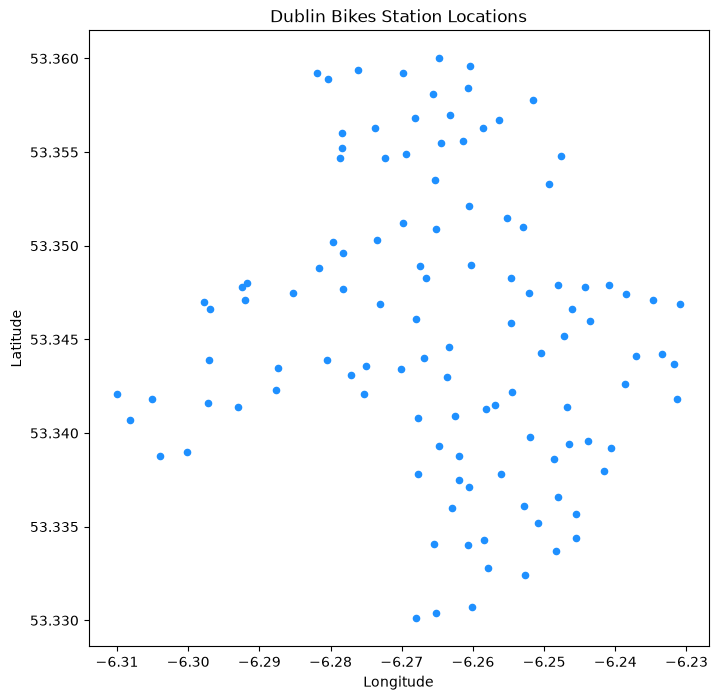

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(station_locations['LONGITUDE'], station_locations['LATITUDE'], s=20, color='dodgerblue')
plt.title("Dublin Bikes Station Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("../dashboard/station_map.png", dpi=150, bbox_inches='tight')
plt.show()